# Final Project - Impact of AI on Students
This is a submission to the final project to the course Supervised Machine Learning: Classification by IBM on Coursera.

In [1]:
#The following packages need to be installed:
!pip install kagglehub[pandas-datasets]
!pip install scikit-learn
!pip install pandas
!pip install numpy
!pip install matplotlib   
!pip install seaborn

In [2]:
#For data handling and processing
import kagglehub
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler, PolynomialFeatures

#For plotting
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('dark')
sns.set_theme('notebook')
sns.set_context('notebook')

#model_selection
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV

#models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

#metrics 
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

/home/reinder/Documents/Code/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Dataset Selection and Description
The dataset used in this notebook is the dataset "Impact of AI on Students" on Kaggle. As someone who recently graduated from university, I'm curious to see how AI usage affects current students. In particular, I will be studying the impact of AI on the risk of burnout among students.

## Source
This data is publicly available on Kaggle. It can be found on the Kaggle wesbite [here](https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students/data). We load it into a pandas dataframe.

In [3]:
# Import the latest version of the data into a pandas DataFrame
kagglehub.dataset_download("laveshjadon/ai-impact-on-students")

df = kagglehub.dataset_load(
  kagglehub.KaggleDatasetAdapter.PANDAS,
  "laveshjadon/ai-impact-on-students",
  'ai_student_impact_dataset (1).csv'
)
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


## Key Features and the Target
We are interested in the features related to AI. Those are the following:
| Feature Name     | Description |
| ----------- | ----------- |
| Weekly_GenAI_Hours      | Average hours per week spent using Generative AI tools      |
| Primary_Use_Case   | Main purpose for which the student uses AI        |
| Prompt_Engineering_Skill   | Self-assessed proficiency in crafting effective prompts        |
| Tool_Diversity      | Number of distinct AI tools used        |
| Perceived_AI_Dependency | Student's self-rated dependency on AI tools |
| Paid_Subscription    | Whether the student has a paid AI subscription        |

The target variable is 'Burnout_Risk_Level'. This is the assesed burnout risk.

We are not interested in any of the other features.

In [4]:
#Eliminate all other features
feature_names = [
    'Weekly_GenAI_Hours',
    'Primary_Use_Case',
    'Prompt_Engineering_Skill',
    'Tool_Diversity',
    'Paid_Subscription',
    'Perceived_AI_Dependency'
]

df = df.drop([
    column for column in df.columns
    if column not in feature_names
    and column != 'Burnout_Risk_Level'
    ],
    axis= 1
)

# Analytical Approach and Model Development
We analyze the dataset. Then we train several models on this dataset.

## Structure
We observe 50k rows, none of which have any missing values. However, there are some string-types and a boolean that will need to be encoded.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Weekly_GenAI_Hours        50000 non-null  float64
 1   Primary_Use_Case          50000 non-null  str    
 2   Prompt_Engineering_Skill  50000 non-null  str    
 3   Tool_Diversity            50000 non-null  int64  
 4   Paid_Subscription         50000 non-null  bool   
 5   Perceived_AI_Dependency   50000 non-null  int64  
 6   Burnout_Risk_Level        50000 non-null  str    
dtypes: bool(1), float64(1), int64(2), str(3)
memory usage: 2.3 MB


The following manipulations are required:
- The target Burnout_Risk_Level needs to be label-encoded
- Primary_Use_Case needs to be one-hot encoded
- Prompt_Engineering_Skill needs to ordinal-encoded
- Paid_Subscription needs to be converted to an integer

In [6]:
## label-encode the target
burnout_encoder = LabelEncoder()
df['Burnout_Risk_Level'] = burnout_encoder.fit_transform(df['Burnout_Risk_Level'])

In [7]:
## Convert Paid_Subscription to int
df['Paid_Subscription'] = df['Paid_Subscription'].astype(int)


In [8]:
## Label encode prompt-engineering skills
df['Prompt_Engineering_Skill'].unique()

<StringArray>
['Beginner', 'Advanced', 'Intermediate']
Length: 3, dtype: str

In [9]:
prompt_engineering_encoder = OrdinalEncoder()

df['Prompt_Engineering_Skill'] = prompt_engineering_encoder.fit_transform(df[['Prompt_Engineering_Skill']])

In [10]:
## One-hot-encode Primary_Use_Case using pandas get_dummies
df = pd.get_dummies(df, drop_first=True, dtype= int)

We observe that every column is now numerical

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Weekly_GenAI_Hours                          50000 non-null  float64
 1   Prompt_Engineering_Skill                    50000 non-null  float64
 2   Tool_Diversity                              50000 non-null  int64  
 3   Paid_Subscription                           50000 non-null  int64  
 4   Perceived_AI_Dependency                     50000 non-null  int64  
 5   Burnout_Risk_Level                          50000 non-null  int64  
 6   Primary_Use_Case_Debugging/Troubleshooting  50000 non-null  int64  
 7   Primary_Use_Case_Direct_Answer_Generation   50000 non-null  int64  
 8   Primary_Use_Case_Ideation                   50000 non-null  int64  
 9   Primary_Use_Case_Summarizing_Reading        50000 non-null  int64  
dtypes: float64(2), int64(

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Weekly_GenAI_Hours,50000.0,8.427752,8.269490,0.0,2.39,5.8,11.72,40.0
Prompt_Engineering_Skill,50000.0,1.077740,0.789980,0.0,0.00,1.0,2.00,2.0
Tool_Diversity,50000.0,2.800260,1.188020,1.0,2.00,3.0,4.00,5.0
Paid_Subscription,50000.0,0.423080,0.494053,0.0,0.00,0.0,1.00,1.0
Perceived_AI_Dependency,50000.0,3.505360,1.820812,1.0,2.00,3.0,5.00,10.0
Burnout_Risk_Level,50000.0,1.173140,0.801658,0.0,1.00,1.0,2.00,2.0
Primary_Use_Case_Debugging/Troubleshooting,50000.0,0.245900,0.430624,0.0,0.00,0.0,0.00,1.0
Primary_Use_Case_Direct_Answer_Generation,50000.0,0.126800,0.332752,0.0,0.00,0.0,0.00,1.0
Primary_Use_Case_Ideation,50000.0,0.214420,0.410423,0.0,0.00,0.0,0.00,1.0
Primary_Use_Case_Summarizing_Reading,50000.0,0.172660,0.377957,0.0,0.00,0.0,0.00,1.0


## Data Analysis
We start by plotting the distribution of the target. 
Observe that the dataset is slightly skewed, but it's not drastic enough to warrant extensive correction. 

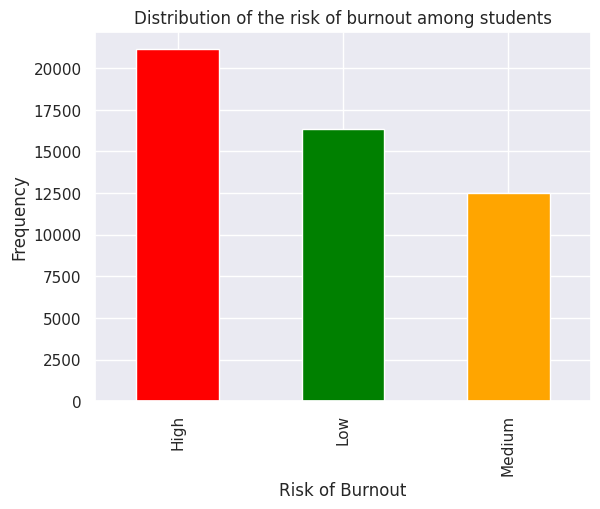

In [13]:
df['Burnout_Risk_Level'].value_counts().plot.bar(color= ['red', 'green', 'orange'])
plt.xlabel('Risk of Burnout')
plt.ylabel('Frequency')
plt.title('Distribution of the risk of burnout among students')
plt.xticks([0, 1, 2], burnout_encoder.inverse_transform([0, 1, 2]));

We proceed to study feature-correlation.

We observe no features are correlated so much that we want to omit them. Of note is that percieved AI dependency is highly related with AI usage.

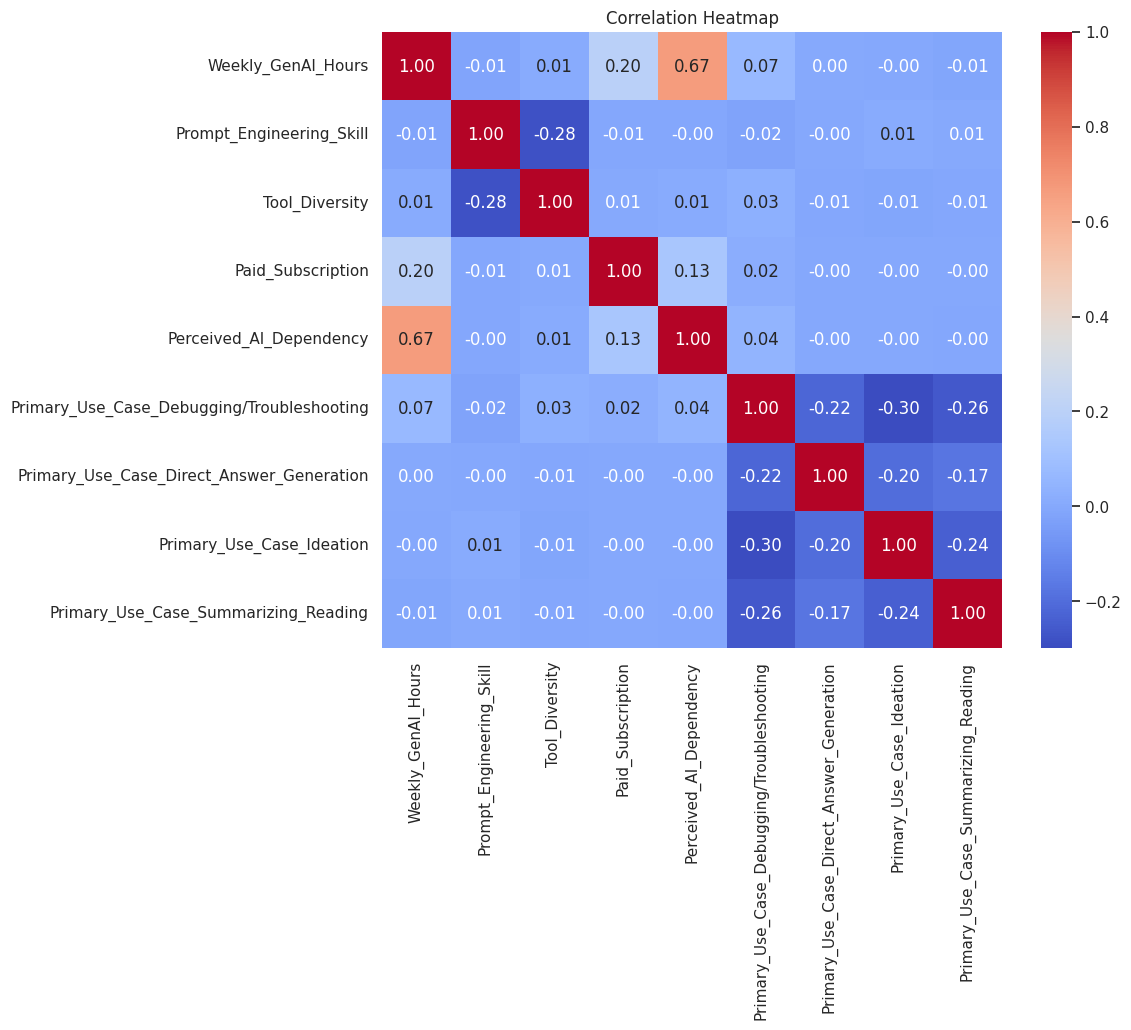

In [14]:
plt.figure(figsize=(10, 8))
corr = df.drop('Burnout_Risk_Level', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Splitting the Data
We use StratifiedShuffleSplit to preserve the distribution presented above.

In [15]:
X = df.drop('Burnout_Risk_Level', axis=1)
y = df['Burnout_Risk_Level']

sss = StratifiedShuffleSplit(test_size= 0.2, random_state=0)
train_idx, test_idx = next(sss.split(X, y))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Fitting models
We fit different types of models, and compare them afterwards.

## Decision Tree Classifier

We first try to fit a decision tree classifier, to see if we are able to overfit the data. It's often easier to regularize an overfit model than to start with regularizating. Note that we will be using accuracy as our metric of choice because this is fine with the dataset being this balanced.

In [16]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

y_pred = dtc.predict(X_test)

print('Training accuracy:', accuracy_score(y_train, dtc.predict(X_train)))
print('Testing accuracy:', accuracy_score(y_test, y_pred))

Training accuracy: 0.98315
Testing accuracy: 0.4162


Now let's regularize the decision tree classifier to obtain better test results.

In [17]:
dtc_param_grid = {
    "max_depth": range(1, 21),
    "max_features": range(1, 10)
}

dtc_search = GridSearchCV(
    estimator= dtc,
    param_grid = dtc_param_grid,
    n_jobs= -1
)

dtc_search.fit(X_train, y_train)
best_dtc = dtc_search.best_estimator_

y_pred = best_dtc.predict(X_test)

print('Training accuracy:', accuracy_score(y_train, best_dtc.predict(X_train)))
print('Testing accuracy:', accuracy_score(y_test, y_pred))

Training accuracy: 0.508125
Testing accuracy: 0.5072


In [18]:
#We verify that we choose the right values for hyperparameter optimalization
dtc_search.best_params_

{'max_depth': 4, 'max_features': 9}

We find an accuracy of approximately 0.5. This is better than guessing, but not extremely strong.

## Logistic Regression
Let's try logistic regression.

In [19]:
lr_steps = [
    ('ss', StandardScaler()),
    ('lr', LogisticRegression())
]

lr_pipe = Pipeline(lr_steps)
lr_pipe.fit(X_train, y_train)

y_pred = lr_pipe.predict(X_test)

print('Training accuracy:', accuracy_score(y_train, lr_pipe.predict(X_train)))
print('Testing accuracy:', accuracy_score(y_test, y_pred))


Training accuracy: 0.507825
Testing accuracy: 0.508


This model isn't powerful enough in its standard form. Let's try adding polynomial features and changing the amount of regularization.

In [20]:
lr_steps = [
    ('pf', PolynomialFeatures(include_bias= False)),
    ('ss', StandardScaler()),
    ('lr', LogisticRegression(max_iter= 1000))
]
lr_pipe = Pipeline(lr_steps)

lr_param_grid = {
    'pf__degree': range(1, 4),
    'lr__C' : [0.01, 0.1, 1.0, 10.0, 100.0]
}

lr_search = GridSearchCV(
    estimator= lr_pipe,
    param_grid= lr_param_grid,
    n_jobs= -1
)

lr_search.fit(X_train, y_train)
best_lr = lr_search.best_estimator_

y_pred = best_lr.predict(X_test)

print('Training accuracy:', accuracy_score(y_train, best_lr.predict(X_train)))
print('Testing accuracy:', accuracy_score(y_test, y_pred))

Training accuracy: 0.5076
Testing accuracy: 0.5079


In [21]:
#We verify that we choose the right values for hyperparameter optimalization
lr_search.best_params_

{'lr__C': 0.01, 'pf__degree': 1}

Adding polynomial features did pretty much nothing. The results after adding polynomial features and tuning the regularization are pretty much identical.

We find an accuracy of approximately 0.5. This is better than guessing, but not extremely strong.

## K nearest Neighbours
We don't have a lot of features, so K nearest is a good model to try as we are not suffering from the curse of dimensionality.

In [22]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print('Training accuracy:', accuracy_score(y_train, knn.predict(X_train)))
print('Testing accuracy:', accuracy_score(y_test, y_pred))

Training accuracy: 0.689825
Testing accuracy: 0.4223


This is better than the logistic regression, so maybe we can find a better model here.

In [23]:
knn_param_grid = {
    'n_neighbors' : range(1, 300, 4)
}

knn_search = GridSearchCV(
    estimator= knn,
    param_grid = knn_param_grid,
    n_jobs= -1
)

knn_search.fit(X_train, y_train)
best_knn = knn_search.best_estimator_

y_pred = best_knn.predict(X_test)

print('Training accuracy:', accuracy_score(y_train, best_knn.predict(X_train)))
print('Testing accuracy:', accuracy_score(y_test, y_pred))

Training accuracy: 0.508975
Testing accuracy: 0.5117


In [24]:
#We verify that we choose the right values for hyperparameter optimalization
knn_search.best_params_

{'n_neighbors': 293}

We seem to get an accuracy of 0.5 again. Still better than guessing.

## Support Vector Machine
The last model covered in this course is SVM. We try that here.

In [25]:
svc = SVC()
svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)

print('Training accuracy:', accuracy_score(y_train, svc.predict(X_train)))
print('Testing accuracy:', accuracy_score(y_test, y_pred))

Training accuracy: 0.507325
Testing accuracy: 0.5094


We immediately obtain equal accuracy without any hyperparameter tuning. We still try our best to improve, but it's unlikely it will work.

In [26]:
svc_param_grid = {
    "C" : [0.1, 1, 10]
}

svc_search = GridSearchCV(
    estimator= svc,
    param_grid= svc_param_grid,
    n_jobs= -1
)

svc_search.fit(X_train, y_train)
best_svc = svc_search.best_estimator_

y_pred = best_svc.predict(X_test)

print('Training accuracy:', accuracy_score(y_train, best_svc.predict(X_train)))
print('Testing accuracy:', accuracy_score(y_test, y_pred))

Training accuracy: 0.5087
Testing accuracy: 0.5085


We obtain an accuracy of 0.5, which is identical to that of our models.

## Stacking all the models together
Let's see what happens when we stack all the models together.

In [27]:
estimators = [
    ('dtc', best_dtc),
    ('lr', best_lr),
    ('knn', best_knn),
    ('svc', best_svc)
]

stack = VotingClassifier(
    estimators= estimators
)
stack.fit(X_train, y_train)

y_pred = stack.predict(X_test)

print('Training accuracy:', accuracy_score(y_train, stack.predict(X_train)))
print('Testing accuracy:', accuracy_score(y_test, y_pred))

Training accuracy: 0.50945
Testing accuracy: 0.5079


It seems that stacking all models still yields an accuracy of 0.5.

# Comparing different models
We give different error metrics of all models, to see if a certain model might be better to predict who has a high risk of burn-out than others.

In [28]:
performance_overview = pd.DataFrame()

models = [
    ('dtc', best_dtc),
    ('lr', best_lr),
    ('knn', best_knn),
    ('svc', best_svc),
    ('stack', stack)
]

for model in models:
    y_pred = model[1].predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)

    score_overview = {
        'accuracy': accuracy,
        'precision_high_risk': precision[0],
        'recall_high_risk': recall[0],
        'f1_high_risk': f1[0]
    }
    
    performance_overview[model[0]] = score_overview

performance_overview   

,dtc,lr,knn,svc,stack
accuracy,0.507200,0.507900,0.511700,0.508500,0.507900
precision_high_risk,0.639744,0.650726,0.648214,0.656250,0.646989
recall_high_risk,0.440929,0.430517,0.436123,0.420505,0.434521
f1_high_risk,0.522048,0.518197,0.521427,0.512570,0.519885


The models perform very similar, but some useful findings:
- logistic regression and support vector machine have the highest precision.
- knn and dtc have the highest recall.
- the stack is somewhere in between.

# Conclusions
All models have an accuracy of around 0.5. Given that there are 3 classes, this is significantly better than guessing!

Hence, we conclude that there is a significant correlation between AI usage among students and risk of burnouts.

## Use of these models
If your goal is to identify as many students as possible with a high risk of burnout, I'd recommend the models Decision Tree Classifier or Support Vector Machine. These models find 45% of all students with a high risk of burnout.

If your goal is to have measures taken to help people with a high risk of burnout be as likely as possible to help someone who actually has a high risk, I'd recommend the models Logistic Regression or K Nearest Neighbors. These models are right 66% percent of the time when identifying a student as 'high risk of burnout'.